In [4]:
import cv2
import numpy as np
import torch
import os

In [5]:
# ===== CLEAR GPU MEMORY =====
import gc
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import cv2
import numpy as np
import matplotlib.pyplot as plt
gc.collect()
torch.cuda.empty_cache()

device = torch.device('cuda')
print("GPUs available:", torch.cuda.device_count())

# ==========================================
# 1. MODEL & LOSS CLASSES
# ==========================================

class ResBlock(nn.Module):
    def __init__(self, channels, dilation=1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=dilation, dilation=dilation)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        return x + self.conv2(self.relu(self.conv1(x)))

# MODEL 1: The Puller (Deep & Narrow, snaps to edges)
class BoundaryPuller(nn.Module):
    def __init__(self):
        super().__init__()
        self.img_stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        self.mask_stem = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        self.pre_loop = nn.Sequential(
            nn.Conv2d(24, 24, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        self.looper = nn.Sequential(
            ResBlock(24, dilation=1),
            ResBlock(24, dilation=2),
            ResBlock(24, dilation=4),
            nn.Conv2d(24, 1, kernel_size=3, padding=1)
        )

    def forward(self, img, init_mask, iters=3):
        img_feats = self.img_stem(img)
        curr_logits = (init_mask - 0.5) * 2.0 

        for _ in range(iters):
            curr_mask = torch.sigmoid(curr_logits)
            mask_feats = self.mask_stem(curr_mask)
            x = torch.cat([img_feats, mask_feats], dim=1)
            x = self.pre_loop(x)
            delta = self.looper(x)
            curr_logits = curr_logits + delta
            
        return torch.sigmoid(curr_logits)


# MODEL 2: The Smoother (Shallow, just irons out the jaggies)
class BoundarySmoother(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(4, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, kernel_size=3, padding=1)
        )

    def forward(self, img, mask):
        x = torch.cat([img, mask], dim=1)
        logits = self.net(x)
        return torch.sigmoid(logits)


# LOSS 1: Just the soft boundary BCE to pull the edge perfectly
class PullerLoss(nn.Module):
    def __init__(self, blur_kernel=11):
        super().__init__()
        self.blur_kernel = blur_kernel

    def forward(self, pred, target):
        dilated = F.max_pool2d(target, kernel_size=3, stride=1, padding=1)
        eroded = -F.max_pool2d(-target, kernel_size=3, stride=1, padding=1)
        gt_boundary = dilated - eroded
        
        soft_glow = F.avg_pool2d(gt_boundary, kernel_size=self.blur_kernel, stride=1, padding=self.blur_kernel//2)
        weight_map = 0.2 + (4.8 * (soft_glow / (soft_glow.max() + 1e-6)))
        
        bce = F.binary_cross_entropy(pred, target, reduction='none')
        return (bce * weight_map).mean()


# LOSS 2: Local Density & Smooth Boundary Loss
class SmoothBoundaryLoss(nn.Module):
    def __init__(self, blur_kernel=31, scatter_weight=2.0):
        super().__init__()
        self.blur_kernel = blur_kernel
        self.scatter_weight = scatter_weight 

    def extract_boundary(self, mask):
        dilated = F.max_pool2d(mask, kernel_size=3, stride=1, padding=1)
        eroded = -F.max_pool2d(-mask, kernel_size=3, stride=1, padding=1)
        return dilated - eroded

    def forward(self, pred, target):
        # 1. Base BCE with soft boundary weights
        gt_boundary = self.extract_boundary(target)
        soft_glow = F.avg_pool2d(gt_boundary, kernel_size=self.blur_kernel, stride=1, padding=self.blur_kernel//2)
        glow_norm = soft_glow / (soft_glow.max() + 1e-6)
        
        weight_map = 0.2 + (4.8 * glow_norm)
        
        bce_loss = F.binary_cross_entropy(pred, target, reduction='none')
        weighted_bce = (bce_loss * weight_map).mean()
        
        # 2. Scattered Pixel / Local Density Loss
        local_density = F.avg_pool2d(pred, kernel_size=7, stride=1, padding=3)
        scatter_penalty = pred * (1.0 - local_density)
        hole_penalty = (1.0 - pred) * local_density
        total_density_penalty = scatter_penalty + hole_penalty
        
        weighted_scatter_loss = (total_density_penalty * weight_map).mean()
        
        return weighted_bce + (self.scatter_weight * weighted_scatter_loss)

GPUs available: 1


Total boundary patches to process: 16


C:\Users\deban\AppData\Local\Temp\ipykernel_35228\3733334420.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model1.load_state_dict(torch.load("./puller_final.pth", map_

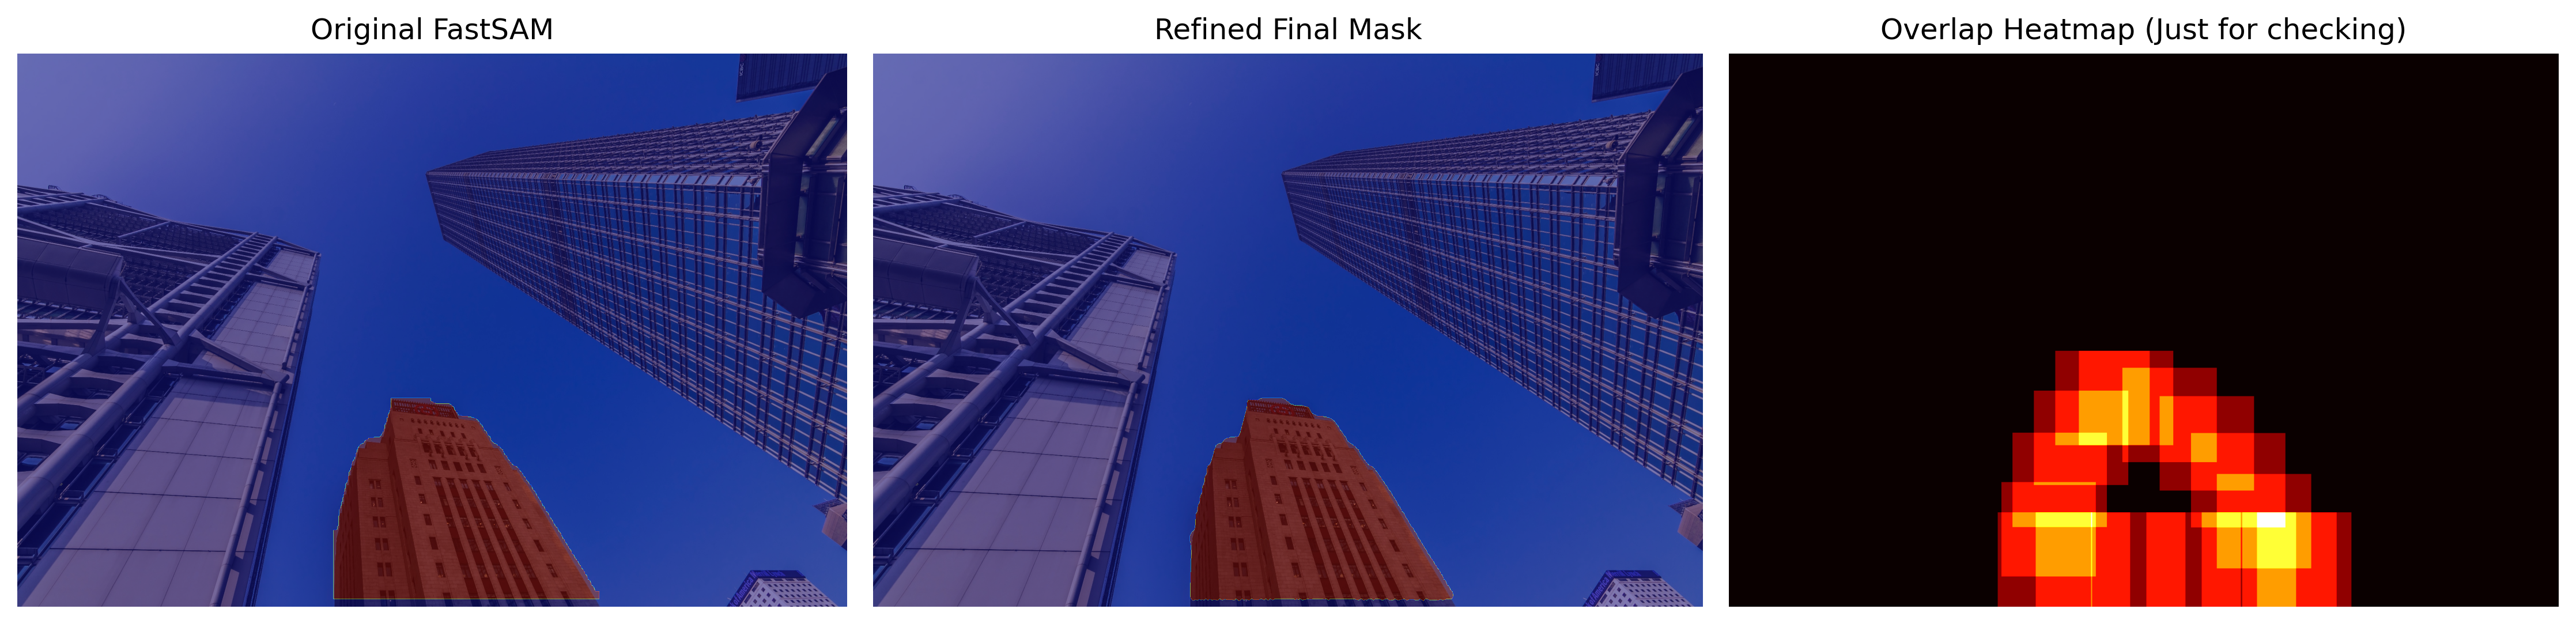

In [ ]:


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Load models from current directory
model1 = BoundaryPuller().to(device)
model1.load_state_dict(torch.load("./puller_final.pth", map_location=device))
model1.eval()

model2 = BoundarySmoother().to(device)
model2.load_state_dict(torch.load("./smoother_final.pth", map_location=device))
model2.eval()

# 2. Read full image and mask
img_path = "image.jpg"
mask_path = "mask.png" # Assuming this is your FastSAM mask

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
H, W, _ = img_rgb.shape

fs_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
fs_bin = (fs_mask > 127).astype(np.float32)

# 3. Setup canvas for merging
# Initialize with the base FastSAM mask so the interior stays intact
full_prob = fs_bin.copy()
full_count = np.ones((H, W), dtype=np.float32)

# 4. Find boundaries to sample patches
fs_uint8 = (fs_bin * 255).astype(np.uint8)
contours, _ = cv2.findContours(fs_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

patch_size = 256
half = patch_size // 2
stride = 150 # Roughly gives that ~40% overlap you want

patch_centers = []
for cnt in contours:
    # Sample points along the boundary based on the stride
    for i in range(0, len(cnt), stride):
        x, y = cnt[i][0]
        patch_centers.append((x, y))

print(f"Total boundary patches to process: {len(patch_centers)}")

# 5. Process each patch
with torch.no_grad():
    for x, y in patch_centers:
        # Get safe box coordinates ensuring exactly 256x256
        x1, x2 = max(0, x - half), min(W, x + half)
        y1, y2 = max(0, y - half), min(H, y + half)
        
        # Shift box if it hits the image edge so we don't get tiny patches
        if x2 - x1 < patch_size:
            if x1 == 0: x2 = min(W, patch_size)
            else: x1 = max(0, W - patch_size)
            
        if y2 - y1 < patch_size:
            if y1 == 0: y2 = min(H, patch_size)
            else: y1 = max(0, H - patch_size)
            
        # Crop patches
        img_patch = img_rgb[y1:y2, x1:x2]
        mask_patch = fs_bin[y1:y2, x1:x2]
        
        # Convert to tensors
        img_t = torch.from_numpy(img_patch.astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device)
        mask_t = torch.from_numpy(mask_patch).unsqueeze(0).unsqueeze(0).to(device)
        
        # Run inference
        m1_out = model1(img_t, mask_t, iters=5)
        m1_bin = (m1_out > 0.5).float()
        m2_out = model2(img_t, m1_bin)
        
        pred_patch = m2_out.squeeze().cpu().numpy()
        
        # Blend into the canvas
        full_prob[y1:y2, x1:x2] += pred_patch
        full_count[y1:y2, x1:x2] += 1

# 6. Average the overlaps and threshold
avg_prob = full_prob / full_count
final_mask = (avg_prob > 0.5).astype(np.uint8)

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5), dpi=300)
plt.subplot(1, 3, 1)
plt.title("Original FastSAM")
plt.imshow(img_rgb)
plt.imshow(fs_bin, alpha=0.5, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Refined Final Mask")
plt.imshow(img_rgb)
plt.imshow(final_mask, alpha=0.5, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Overlap Heatmap (Just for checking)")
plt.imshow(full_count, cmap='hot')
plt.axis('off')

plt.tight_layout()
plt.show()